## Water Quality and Potability Classification | 99% Accuracy | 

Liberías del proyecto 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.feature_selection import f_classif, mutual_info_classif
import tensorflow as tf
from keras import Model
from keras.layers import Input, Dense, Dropout
from keras.layers import LSTM
from sklearn.impute import KNNImputer
from sklearn.utils import resample
import seaborn as sns 
import math
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)


Importar Datos 

In [2]:
df = pd.read_csv('water_potability.csv')
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


Información del dataset de pandas

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


## 1. Preprocesamiento de datos

Eliminar duplicados

In [4]:
df.drop_duplicates(inplace=True)


Separamos la variable objetivo (Potability) de las características

In [5]:
X = df.drop('Potability', axis=1)
y = df['Potability']

Comprobar si existen valores faltantes

In [6]:
df.isnull().sum().sum()

np.int64(1434)

Al calcular distancias, para más adelante realizar el suavizado de datos, escalamos los datos

In [7]:
scaler = MinMaxScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

Suavizado de Datos

In [8]:
imputer = KNNImputer(n_neighbors=5, weights="distance")

X_final = pd.DataFrame(imputer.fit_transform(X_scaled), columns=X.columns)


Comprobación nulos despés del suavizado

In [9]:
print("Valores nulos después del suavizado:")
print(X_final.isnull().sum())

Valores nulos después del suavizado:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64


Unir datos suavizados, para poder identificar quién es quién

In [10]:
df_suavizado = pd.concat([X_final, y.reset_index(drop=True)], axis=1)

Selección de atributos

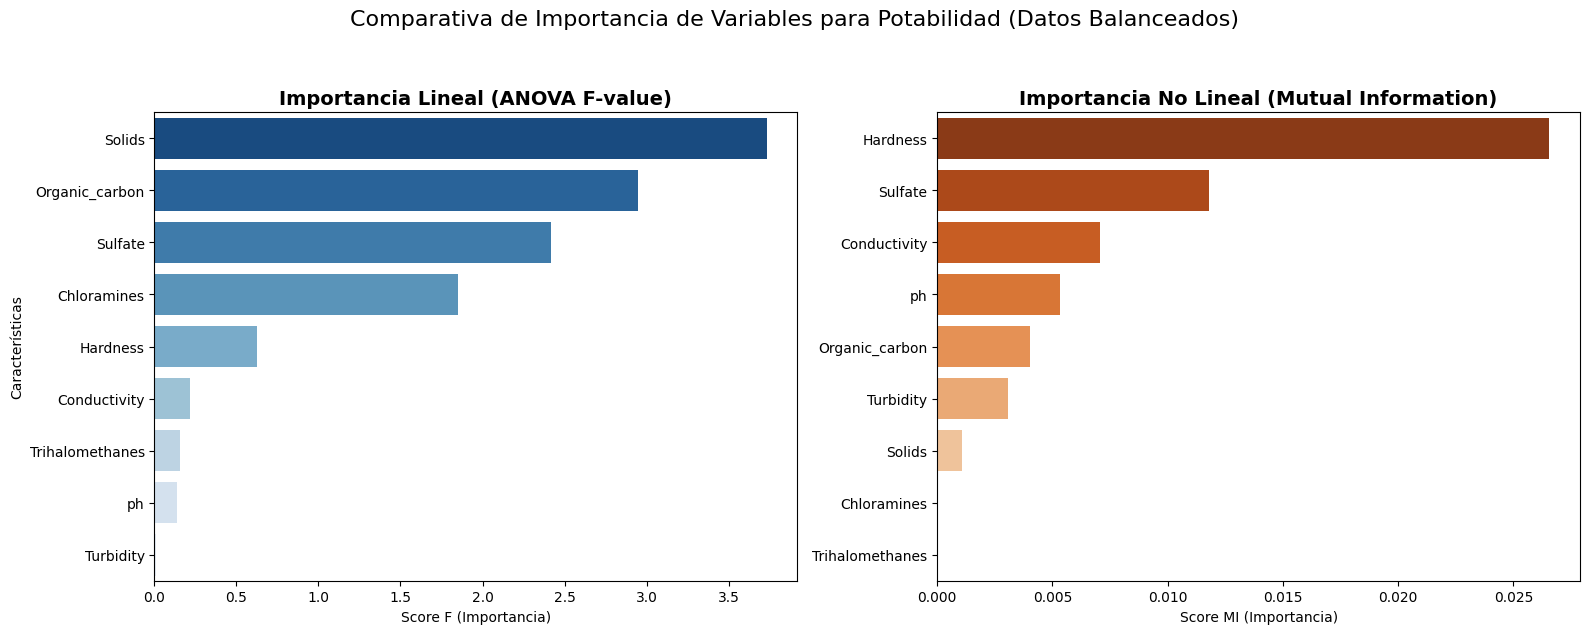

In [11]:

X_prep = df_suavizado.drop('Potability', axis=1)
y_prep = df_suavizado['Potability']

# Calculamos ANOVA F-value (Relaciones lineales)
f_scores, p_values = f_classif(X_prep, y_prep)
df_anova = pd.DataFrame({'Variable': X_prep.columns, 'F_Score': f_scores})
df_anova = df_anova.sort_values(by='F_Score', ascending=False)

# Calculamos Mutual Information (Relaciones no lineales)
mi_scores = mutual_info_classif(X_prep, y_prep, random_state=42)
df_mi = pd.DataFrame({'Variable': X_prep.columns, 'MI_Score': mi_scores})
df_mi = df_mi.sort_values(by='MI_Score', ascending=False)

# =========================================================
# VISUALIZACIÓN COMPARATIVA
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico para ANOVA
sns.barplot(data=df_anova, x='F_Score', y='Variable', ax=axes[0], palette='Blues_r')
axes[0].set_title('Importancia Lineal (ANOVA F-value)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score F (Importancia)')
axes[0].set_ylabel('Características')

# Gráfico para Mutual Information
sns.barplot(data=df_mi, x='MI_Score', y='Variable', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Importancia No Lineal (Mutual Information)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score MI (Importancia)')
axes[1].set_ylabel('') 

plt.suptitle("Comparativa de Importancia de Variables para Potabilidad (Datos Balanceados)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [12]:
top_n = 7

# Extraemos los nombres de las 7 mejores características con mayor puntuación
columnas_importantes = df_mi.head(top_n)['Variable'].tolist()

print(f"=== SELECCIONANDO LAS {top_n} VARIABLES MÁS IMPORTANTES ===")
for i, col in enumerate(columnas_importantes, 1):
    print(f"{i}. {col}")

# Creamos la lista final de columnas incluyendo nuestro target
columnas_finales = columnas_importantes + ['Potability']

# Filtramos el dataset suavizado original 
df_final_filtrado = df_suavizado[columnas_finales]

print(f"\nDimensiones del nuevo dataset filtrado: {df_final_filtrado.shape}")

# Mostramos una vista previa del dataset que usaremos para los modelos
df_final_filtrado.head()

=== SELECCIONANDO LAS 7 VARIABLES MÁS IMPORTANTES ===
1. Hardness
2. Sulfate
3. Conductivity
4. ph
5. Organic_carbon
6. Turbidity
7. Solids

Dimensiones del nuevo dataset filtrado: (3276, 8)


,Hardness,Sulfate,Conductivity,ph,Organic_carbon,Turbidity,Solids,Potability
0,0.571139,0.680385,0.669439,0.475399,0.313402,0.286091,0.336096,0
1,0.297400,0.633201,0.719411,0.265434,0.497319,0.576793,0.300611,0
2,0.641311,0.561942,0.414652,0.578509,0.562017,0.303637,0.321619,0
3,0.605536,0.647347,0.317880,0.594055,0.622089,0.601015,0.356244,0
4,0.484851,0.514545,0.379337,0.649445,0.358555,0.496327,0.289922,0


In [13]:
# Guardamos el CSV 
df_final_filtrado.to_csv('water_preprocessed.csv', index=False)

## 2. Visualización:

In [14]:
print("\n=== INFORMACIÓN DEL DATASET ===")
print(f"Dimensiones de X: {X.shape}")
print(f"Distribución de clases:\n{y.value_counts().sort_index()}")

df_viz = X.copy()
df_viz["target"] = y

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()


=== INFORMACIÓN DEL DATASET ===
Dimensiones de X: (3276, 9)
Distribución de clases:
Potability
0    1998
1    1278
Name: count, dtype: int64


### 2.1 Scatter Plot:

<Figure size 1200x1200 with 0 Axes>

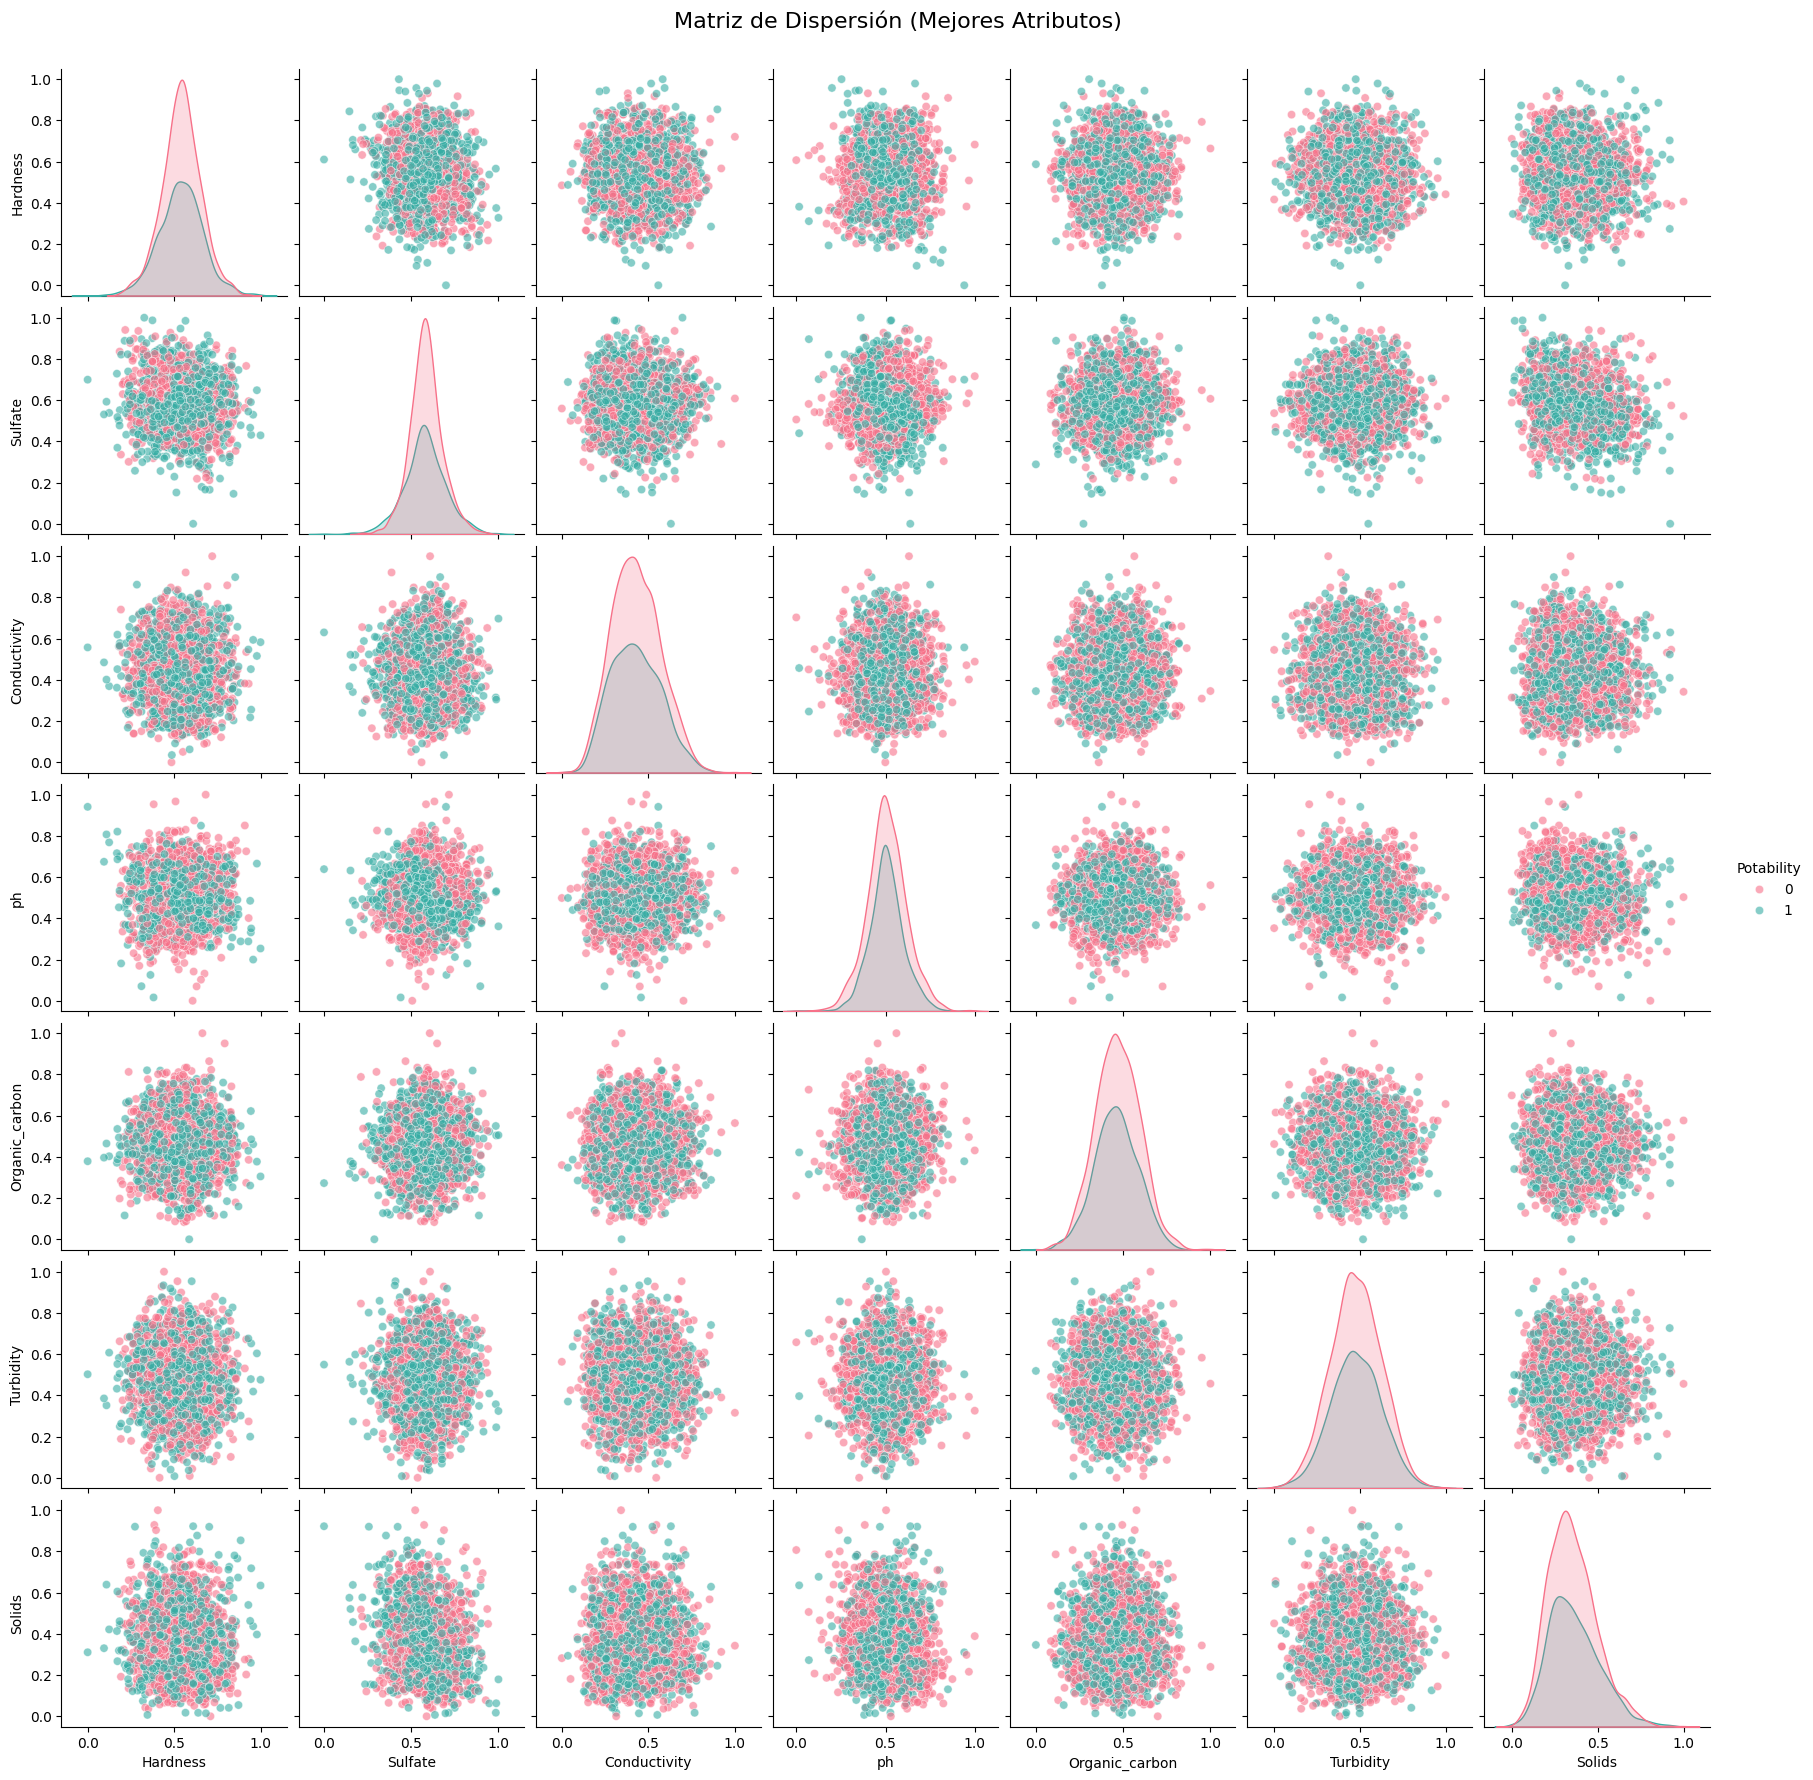

In [15]:
plt.figure(figsize=(12, 12))

# Usamos df_final_filtrado y hue="Potability"
sns.pairplot(df_final_filtrado, hue="Potability", palette="husl", plot_kws={'alpha':0.6})
plt.suptitle("Matriz de Dispersión (Mejores Atributos)", y=1.02, fontsize=16)
plt.show()

### 2.2 Histogramas

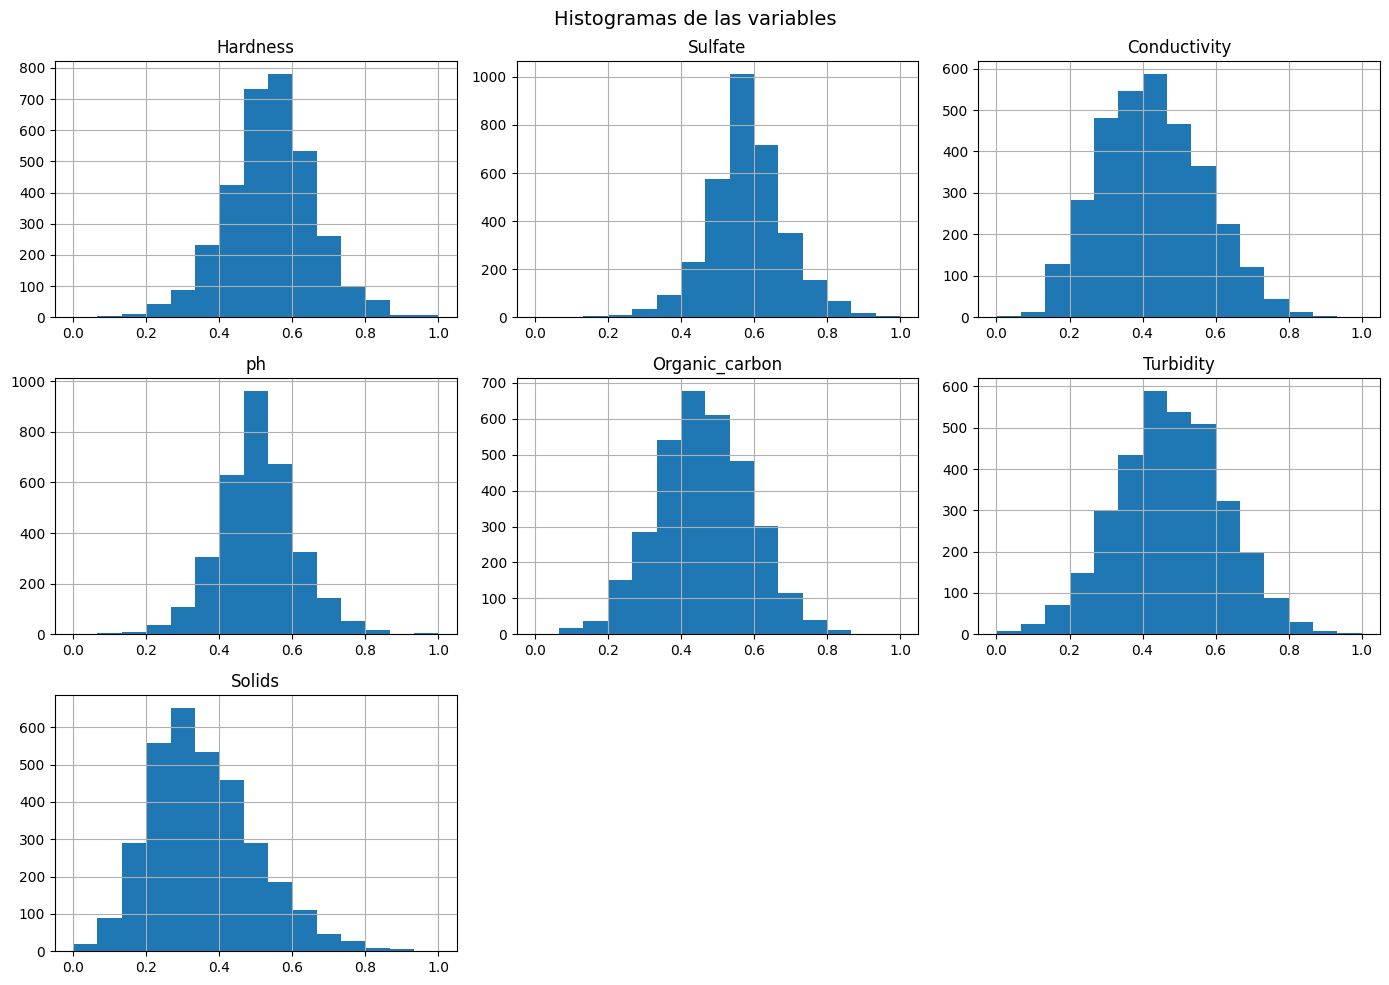

In [16]:
X_filtrado = df_final_filtrado.drop(columns=['Potability'])
X_filtrado.hist(figsize=(14, 10), bins=15)
plt.suptitle("Histogramas de las variables", fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Diagramas de Barras

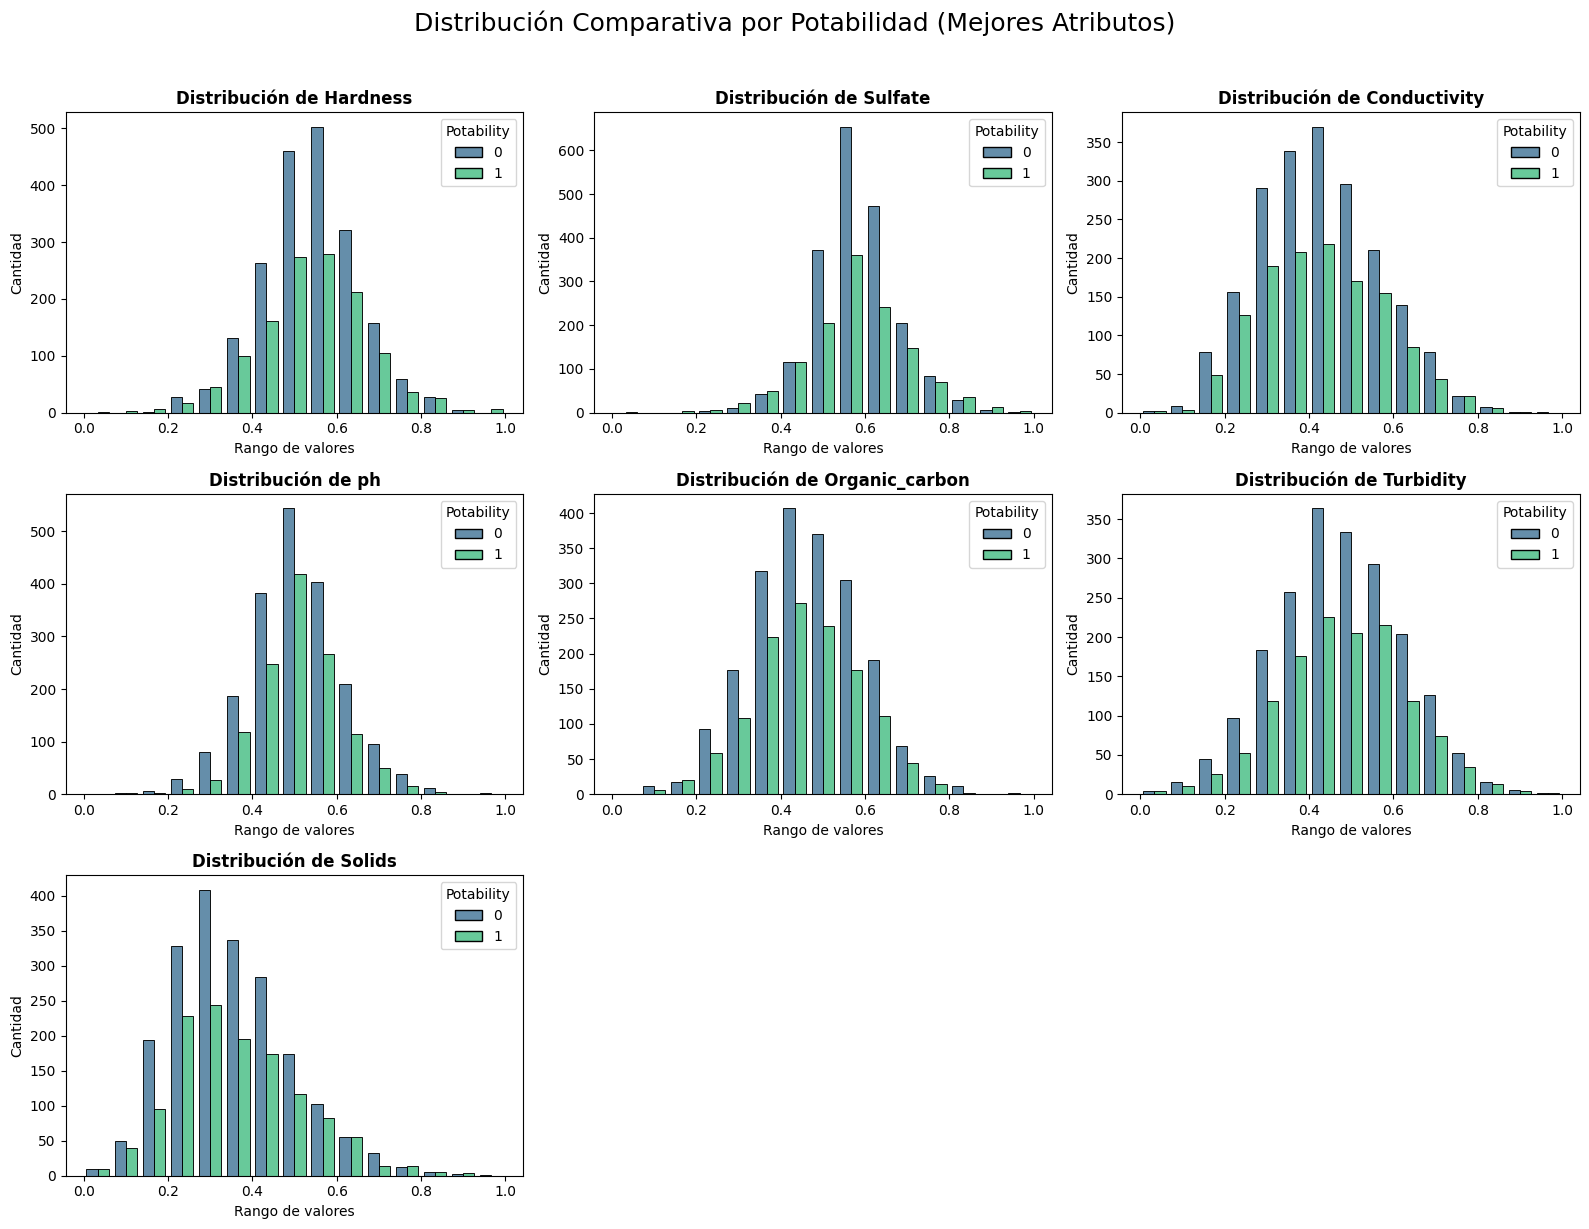

In [17]:
# Identificamos las columnas filtradas excluyendo 'Potability'
variables_filtradas = [col for col in df_final_filtrado.columns if col != 'Potability']

# Configuramos la cuadrícula 
n_cols = 3
n_rows = math.ceil(len(variables_filtradas) / n_cols)

# Creamos la figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

# Iteramos solo sobre las variables filtradas
for i, col in enumerate(variables_filtradas):
    sns.histplot(
        data=df_final_filtrado, 
        x=col, 
        hue='Potability', 
        multiple='dodge', 
        bins=15, 
        ax=axes[i],
        palette='viridis',
        shrink=0.8
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Rango de valores')
    axes[i].set_ylabel('Cantidad')

# Eliminamos recuadros vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución Comparativa por Potabilidad (Mejores Atributos)", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 2.4 Matriz de Correlación de las variables

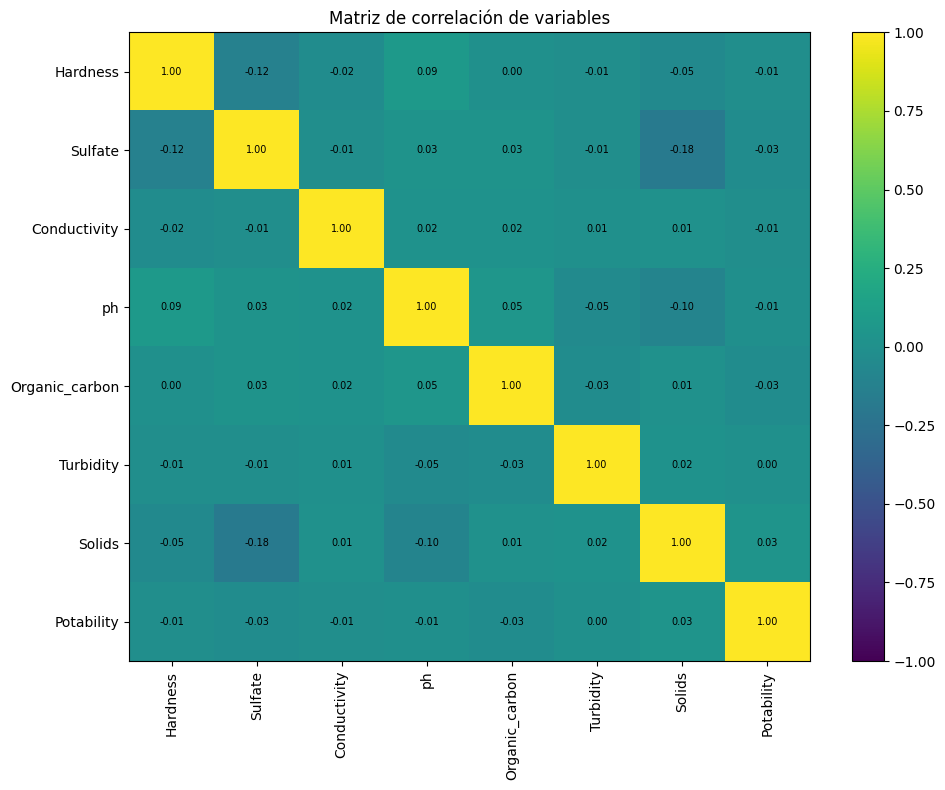

In [18]:
corr_matrix = df_final_filtrado.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, interpolation="nearest", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Matriz de correlación de variables")

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.show()

### 2.5 Diagramas de caja


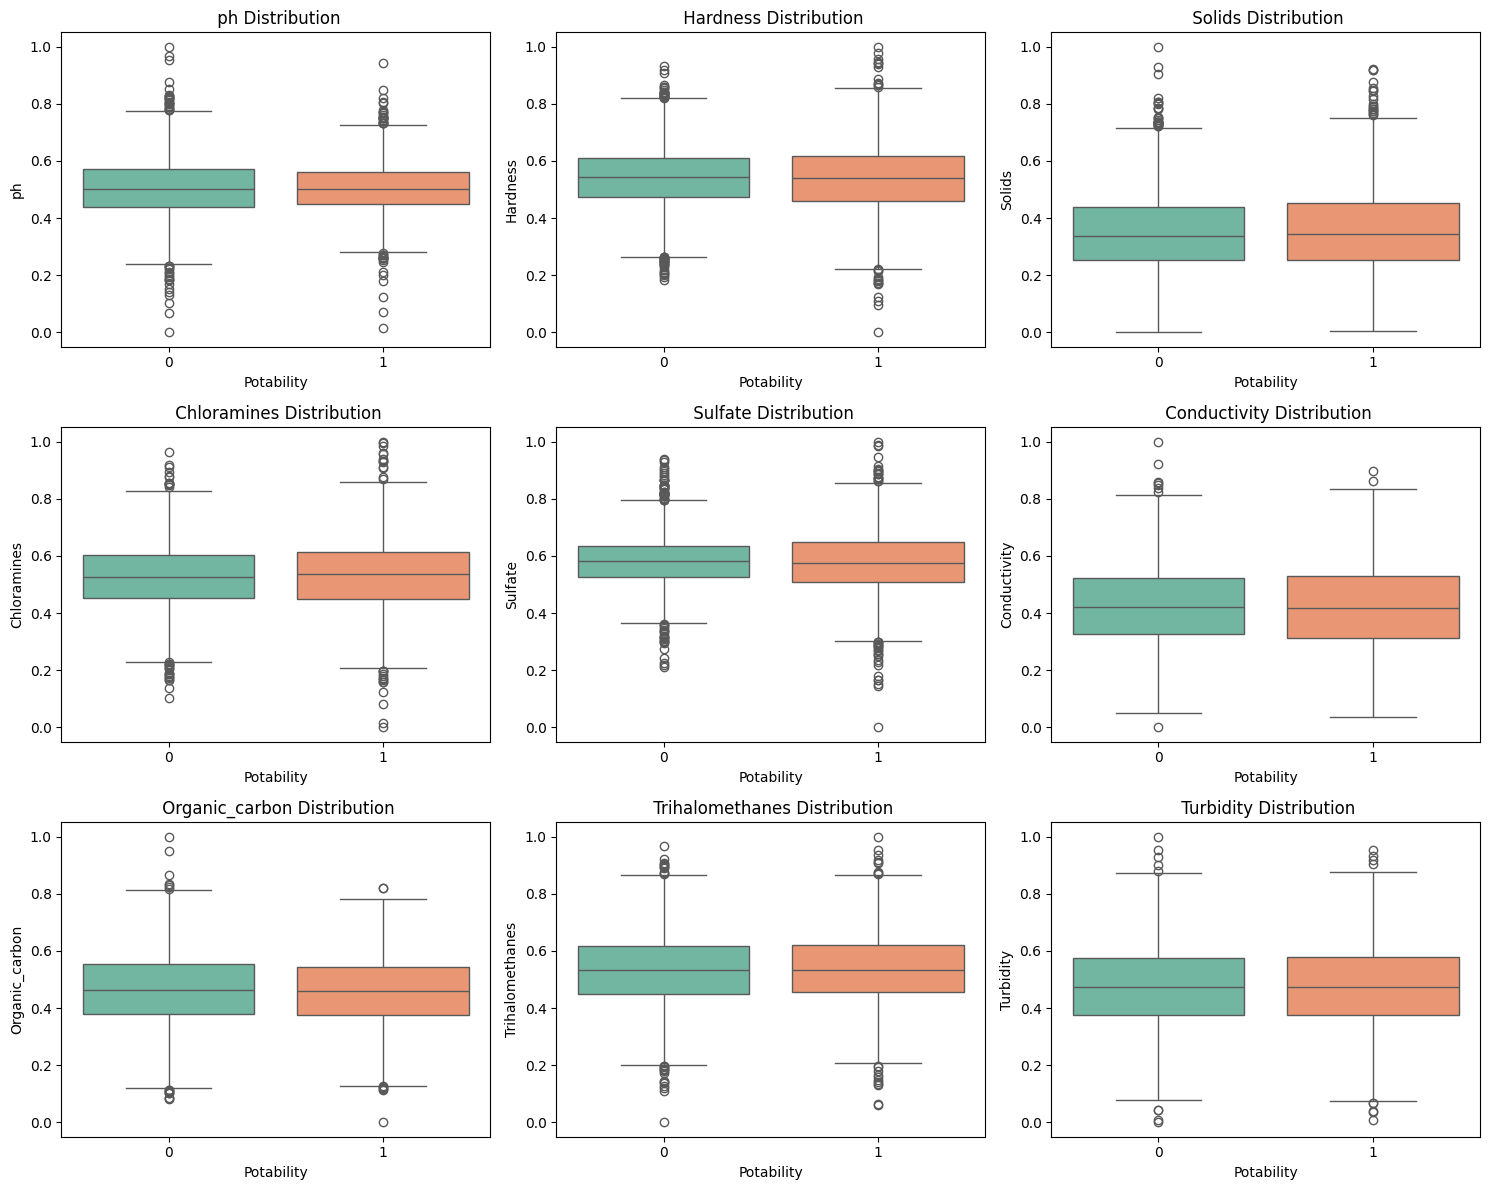

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas_features = [col for col in df_suavizado.columns if col != 'Potability']

plt.figure(figsize=(15, 12))

for i, col in enumerate(columnas_features, 1):
    plt.subplot(3, 3, i) # Asumiendo que tienes 9 variables predictoras (3x3)
    sns.boxplot(data=df_suavizado, x='Potability', y=col, palette='Set2')
    plt.title(f' {col} Distribution')
    plt.xlabel('Potability')
    plt.ylabel(col)

# Ajustamos el layout para que no se superpongan y mostramos
plt.tight_layout()
plt.show()

## 3. Estructura de la red neuronal 

In [ ]:
# =========================================================
# 4. DIVISIÓN Y BALANCEO 
# =========================================================
# Primero dividimos
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Balanceamos sólo el entrenamiento
df_train = pd.concat([X_train_raw, y_train_raw], axis=1)
df_0 = df_train[df_train['Potability'] == 0]
df_1 = df_train[df_train['Potability'] == 1]
df_1_ups = resample(df_1, replace=True, n_samples=len(df_0), random_state=42)
df_balanced = pd.concat([df_0, df_1_ups])

X_train = df_balanced.drop('Potability', axis=1)
y_train = df_balanced['Potability']

# =========================================================
# 5. MODELO FINAL 
# =========================================================
modelo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128,64,32),
        activation="relu",
        solver="adam",
        alpha=1e-5,
        batch_size=32,
        learning_rate_init=0.001,
        max_iter=5000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42
    ))
])

print("\n=== ARQUITECTURA DE LA RED ===")
print("Capas ocultas:", modelo.named_steps["mlp"].hidden_layer_sizes)
print("Función de activación:", modelo.named_steps["mlp"].activation)


=== ARQUITECTURA DE LA RED ===
Capas ocultas: (128, 64, 32)
Función de activación: relu


VALIDACIÓN CRUZADA K-FOLD

In [21]:
# Definimos el número de folds y detectamos clases
requested_folds = 10
n_classes = len(np.unique(y_train)) 
min_class_count = int(pd.Series(y_train).value_counts().min())

# Ajuste automático de K si hay pocos datos
if min_class_count < requested_folds:
    n_splits = min_class_count
else:
    n_splits = requested_folds

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Configuración de métricas para clasificación binaria 
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Ejecución de la validación cruzada usando el Pipeline
cv_results = cross_validate(
    modelo, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring=scoring, 
    return_train_score=False, 
    n_jobs=-1
)

print(f"\n=== RESULTADOS VALIDACIÓN CRUZADA ({n_splits}-FOLD) ===")
for metric in scoring.keys():
    scores = cv_results[f"test_{metric}"]
    print(f"{metric.upper():20s}: {scores.mean():.4f} ± {scores.std():.4f}")

# Predicciones globales para la matriz de confusión final
y_pred_cv = cross_val_predict(modelo, X_train, y_train, cv=cv, method="predict", n_jobs=-1)
y_prob_cv = cross_val_predict(modelo, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)


=== RESULTADOS VALIDACIÓN CRUZADA (10-FOLD) ===
ACCURACY            : 0.7891 ± 0.0278
PRECISION           : 0.7721 ± 0.0279
RECALL              : 0.8216 ± 0.0421
F1                  : 0.7955 ± 0.0277
ROC_AUC             : 0.8363 ± 0.0280


## 4. Evaluación global


=== EVALUACIÓN GLOBAL (CV) ===
Accuracy Promedio: 78.9092%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      1586
           1       0.77      0.82      0.80      1586

    accuracy                           0.79      3172
   macro avg       0.79      0.79      0.79      3172
weighted avg       0.79      0.79      0.79      3172

ROC AUC:  0.8365


<Figure size 800x600 with 0 Axes>

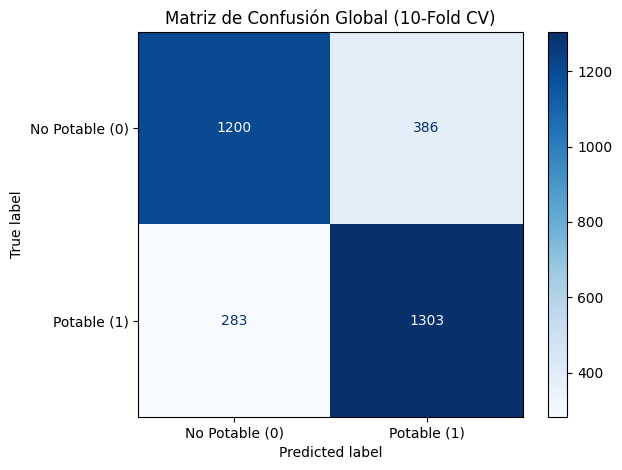

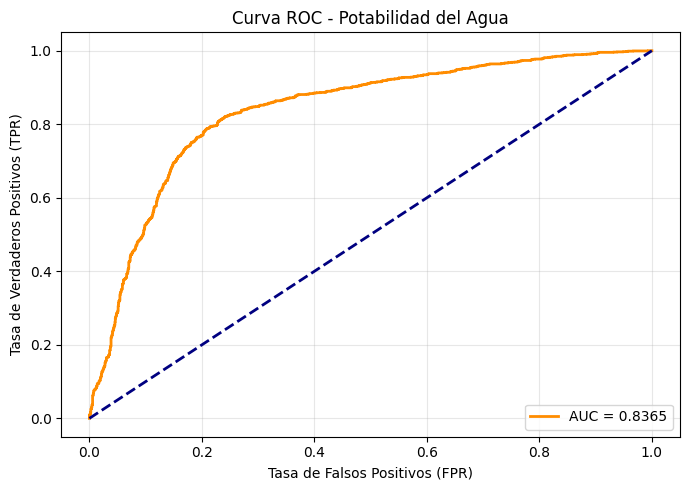


=== RED ENTRENADA FINAL (METADATOS) ===
Estructura de capas ocultas: (128, 64, 32)
Función de activación: relu
Número total de capas: 5
Clases de salida: [0 1]
Iteraciones necesarias para converger: 99


In [22]:
# Usamos los resultados que generamos en el paso anterior 
acc = accuracy_score(y_train, y_pred_cv)
classes = np.unique(y_train)
n_classes = len(classes)

print("\n=== EVALUACIÓN GLOBAL (CV) ===")
print(f"Accuracy Promedio: {acc* 100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_train, y_pred_cv))

# Cálculo del AUC
if n_classes == 2:
    # y_prob_cv[:, 1] es la probabilidad de que el agua sea potable (clase 1)
    auc = roc_auc_score(y_train, y_prob_cv[:, 1])
    print(f"ROC AUC:  {auc:.4f}")
else:
    auc = roc_auc_score(y_train, y_prob_cv, multi_class="ovr", average="weighted")
    print(f"ROC AUC OVR Weighted: {auc:.4f}")

# Matriz de confusión visual
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_train, y_pred_cv, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Potable (0)", "Potable (1)"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión Global (10-Fold CV)")
plt.tight_layout()
plt.show()

# =========================================================
# 6. CURVAS ROC
# =========================================================
if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_train, y_prob_cv[:, 1])
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle="--")
    plt.xlabel("Tasa de Falsos Positivos (FPR)")
    plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
    plt.title("Curva ROC - Potabilidad del Agua")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # Código para multiclase 
    y_bin = label_binarize(y_train, classes=classes)
    plt.figure(figsize=(10, 7))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob_cv[:, i])
        auc_cls = roc_auc_score(y_bin[:, i], y_prob_cv[:, i])
        plt.plot(fpr, tpr, label=f"Clase {cls} (AUC = {auc_cls:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.legend()
    plt.show()

# =========================================================
# 7. ENTRENAR MODELO FINAL SOBRE EL CONJUNTO
# =========================================================
# Entrenamos el Pipeline modelo con todos los datos balanceados
modelo.fit(X_train, y_train)

mlp_final = modelo.named_steps["mlp"]
print("\n=== RED ENTRENADA FINAL (METADATOS) ===")
print("Estructura de capas ocultas:", mlp_final.hidden_layer_sizes)
print("Función de activación:", mlp_final.activation)
print("Número total de capas:", mlp_final.n_layers_)
print("Clases de salida:", mlp_final.classes_)
print("Iteraciones necesarias para converger:", mlp_final.n_iter_)